<div style="background-color:#FFDBDA; padding:20px; border-radius:12px;">

<h1 style="color:#604D53; text-align:center;">CelebA Dataset Analysis</h1>

<p style="color:#604D53; font-size:15px;">

Project analyzes the CelebA dataset, which contains face images. The goal is to explore patterns in facial attributes, discover relationships between gender, makeup, attractiveness and other features and test hypotheses about these relationships.

The analysis covers exploratory data analysis (EDA), descriptive statistics, data visualization and hypothesis testing. The project also includes a desktop application built with Flet that uses FaceNet embeddings to find celebrity lookalikes from the CelebA dataset.

</p>

<hr style="border-color:#DB7F8E;">

<p style="color:#604D53; font-size:14px;">
<b>Contribution:</b><br>
<i>Anastasiia</i> — data loading, overview, cleanup, transformation, statistics, hypotheses 1, 2.<br>
<i>Elena</i> — overview plots and summaries, detailed overview, hypotheses 3, 4.
</p>

</div>

# Dataset Loading

Loading the CelebA attributes file using pandas. 
CelebA contains 202 599 face images with 40 binary attributes each (such as Smiling, Male, Young, Attractive, etc.).
Values are encoded as 1 (attribute present) and -1 (attribute absent).

The preview of the first 5 rows of the raw dataset (skipping the first row since it contains only the total image count and using image filename as the index):

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('data/list_attr_celeba.txt', skiprows=1, sep='\s+', index_col=0)

df.head()

,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,-1,1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,1,1,-1,1,-1,1,-1,-1,1
000002.jpg,-1,-1,-1,1,-1,-1,-1,1,-1,-1,...,-1,1,-1,-1,-1,-1,-1,-1,-1,1
000003.jpg,-1,-1,-1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,1,-1,-1,-1,-1,-1,1
000004.jpg,-1,-1,1,-1,-1,-1,-1,-1,-1,-1,...,-1,-1,1,-1,1,-1,1,1,-1,1
000005.jpg,-1,1,1,-1,-1,-1,1,-1,-1,-1,...,-1,-1,-1,-1,-1,-1,1,-1,-1,1


# Dataset overview

Checking the basic structure of the dataset: 
Number of rows and columns, missing values and full list of attributes

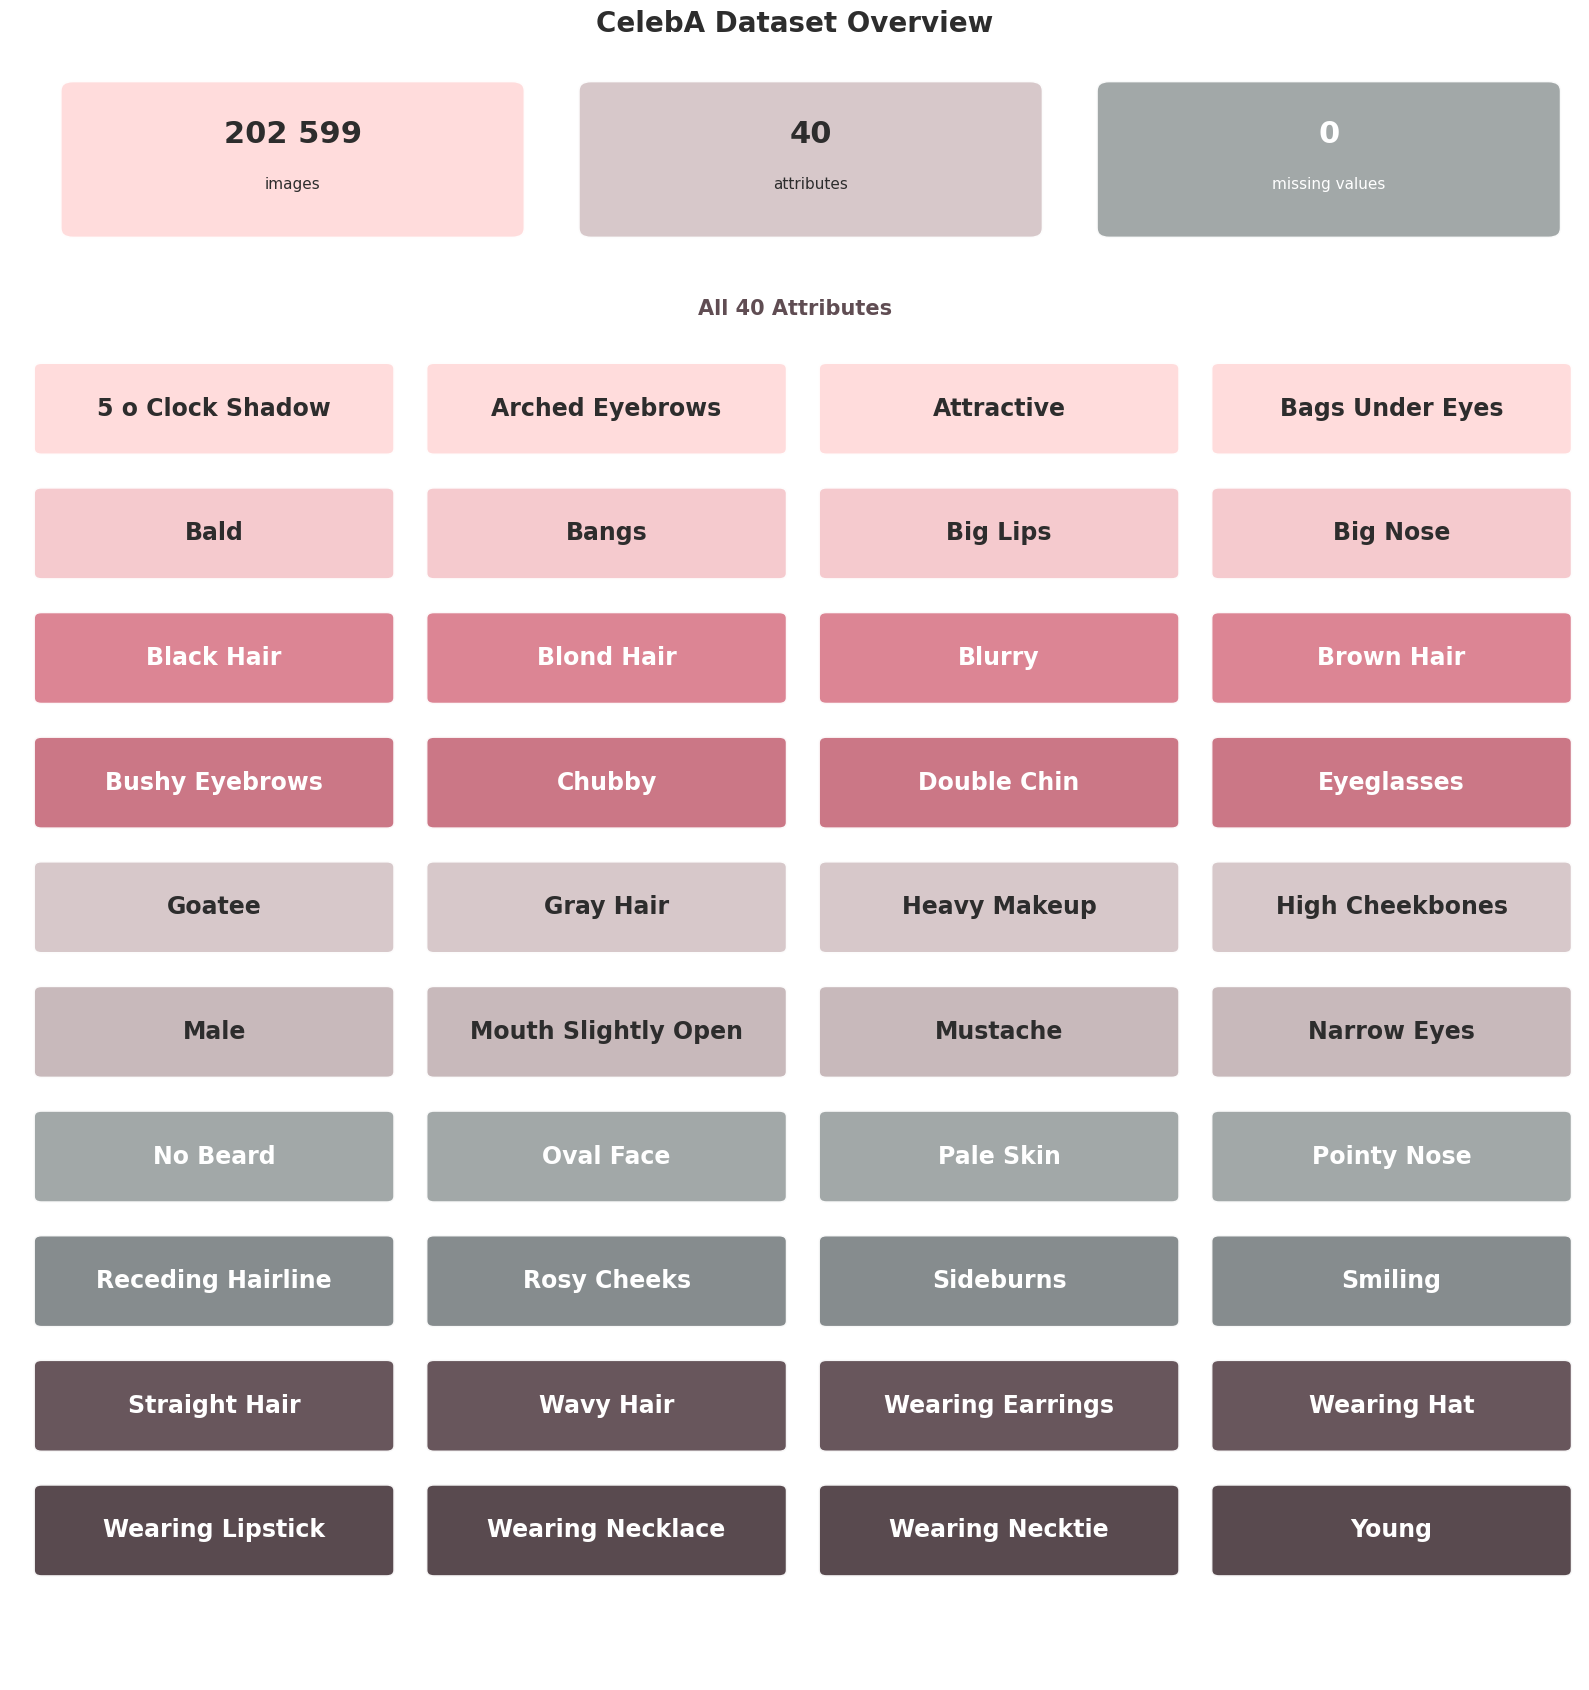

In [2]:
import matplotlib.patches as mpatches

attrs_clean = [col.replace('_', ' ') for col in df.columns.tolist()]

fig, ax = plt.subplots(figsize=(16, 17))
ax.set_xlim(0, 10)
ax.set_ylim(1, 14)
ax.axis('off')

info_data = [
    ('202 599', 'images'),
    ('40', 'attributes'),
    ('0', 'missing values'),
]
info_colors = ['#FFDBDA', '#D5C5C8', '#9DA3A4']
info_text_colors = ['#2D2D2D', '#2D2D2D', '#FFFFFF']

for i, (val, label) in enumerate(info_data):
    x = i * 3.3 + 1.8
    y = 13.2
    fancy = mpatches.FancyBboxPatch(
        (x - 1.4, y - 0.55), 2.8, 1.1,
        boxstyle="round,pad=0.08",
        facecolor=info_colors[i],
        edgecolor='white',
        linewidth=2,
        alpha=0.95
    )
    ax.add_patch(fancy)
    ax.text(x, y + 0.2, val, ha='center', va='center',
            fontsize=22, fontweight='bold', color=info_text_colors[i])
    ax.text(x, y - 0.2, label, ha='center', va='center',
            fontsize=11, color=info_text_colors[i])

ax.set_title('CelebA Dataset Overview', 
             fontsize=20, fontweight='bold', 
             color='#2D2D2D', pad=20)

ax.text(5, 12.0, 'All 40 Attributes', ha='center', va='center',
        fontsize=15, fontweight='bold', color='#604D53')

cols = 4
row_colors = [
    '#FFDBDA', '#F5C8CC', '#DB7F8E', '#C97080',
    '#D5C5C8', '#C5B5B8', '#9DA3A4', '#808688',
    '#604D53', '#504045'
]
text_colors = [
    '#2D2D2D', '#2D2D2D', '#FFFFFF', '#FFFFFF',
    '#2D2D2D', '#2D2D2D', '#FFFFFF', '#FFFFFF',
    '#FFFFFF', '#FFFFFF'
]

for i, attr in enumerate(attrs_clean):
    row = i // cols
    col = i % cols
    x = col * 2.5 + 1.3
    y = 11.2 - row * 1.0
    color = row_colors[row % len(row_colors)]
    text_color = text_colors[row % len(text_colors)]

    fancy = mpatches.FancyBboxPatch(
        (x - 1.1, y - 0.32), 2.2, 0.64,
        boxstyle="round,pad=0.05",
        facecolor=color,
        edgecolor='white',
        linewidth=2,
        alpha=0.95
    )
    ax.add_patch(fancy)
    ax.text(x, y, attr, ha='center', va='center',
            fontsize=17, fontweight='bold', color=text_color)

plt.tight_layout()
plt.show()

So, the dataset contains 202 599 images with 40 attributes each.
It has no missing values, so it is complete and ready for analysis.

# Data cleanup

Dataset uses 1 and -1 as binary values, so we convert them to 1 and 0 for easier analysis and visualization. 

Verify that all columns have the correct data type (integer).

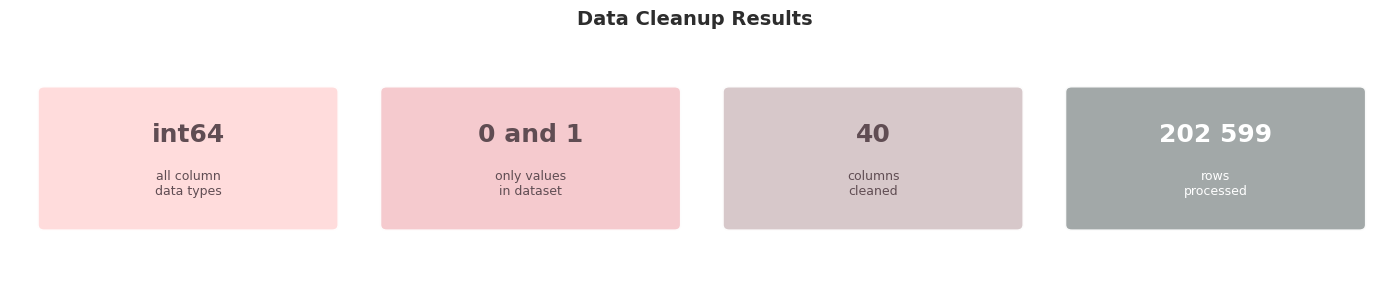

In [3]:
fig, ax = plt.subplots(figsize=(14, 3))
ax.set_xlim(0, 10)
ax.set_ylim(0, 2)
ax.axis('off')

results = [
    ('int64', 'all column\ndata types'),
    ('0 and 1', 'only values\nin dataset'),
    ('40', 'columns\ncleaned'),
    ('202 599', 'rows\nprocessed'),
]
colors = ['#FFDBDA', '#F5C8CC', '#D5C5C8', '#9DA3A4']
text_colors = ['#604D53', '#604D53', '#604D53', '#FFFFFF']

for i, (val, label) in enumerate(results):
    x = i * 2.5 + 1.3
    y = 1.0
    fancy = mpatches.FancyBboxPatch(
        (x - 1.05, y - 0.55), 2.1, 1.1,
        boxstyle="round,pad=0.05",
        facecolor=colors[i],
        edgecolor='white',
        linewidth=2,
        alpha=0.95
    )
    ax.add_patch(fancy)
    ax.text(x, y + 0.2, val, ha='center', va='center',
            fontsize=18, fontweight='bold', color=text_colors[i])
    ax.text(x, y - 0.2, label, ha='center', va='center',
            fontsize=9, color=text_colors[i])

ax.set_title('Data Cleanup Results', fontsize=14, 
             fontweight='bold', color='#2D2D2D', pad=10)
plt.tight_layout()
plt.show()

New preview of first 5 rows of the dataset:

In [4]:
df_clean = df.replace(-1, 0)
print(df_clean.stack().unique())
df_clean.head()

[0 1]


,5_o_Clock_Shadow,Arched_Eyebrows,Attractive,Bags_Under_Eyes,Bald,Bangs,Big_Lips,Big_Nose,Black_Hair,Blond_Hair,...,Sideburns,Smiling,Straight_Hair,Wavy_Hair,Wearing_Earrings,Wearing_Hat,Wearing_Lipstick,Wearing_Necklace,Wearing_Necktie,Young
000001.jpg,0,1,1,0,0,0,0,0,0,0,...,0,1,1,0,1,0,1,0,0,1
000002.jpg,0,0,0,1,0,0,0,1,0,0,...,0,1,0,0,0,0,0,0,0,1
000003.jpg,0,0,0,0,0,0,1,0,0,0,...,0,0,0,1,0,0,0,0,0,1
000004.jpg,0,0,1,0,0,0,0,0,0,0,...,0,0,1,0,1,0,1,1,0,1
000005.jpg,0,1,1,0,0,0,1,0,0,0,...,0,0,0,0,0,0,1,0,0,1


# Data transformation

Creating 4 new numerical columns based on existing binary attributes.

In [5]:
original_cols = df.columns.tolist()
df_clean['attr_sum'] = df_clean[original_cols].sum(axis=1)

makeup_cols = ['Heavy_Makeup', 'Wearing_Lipstick', 'Rosy_Cheeks', 
               'Wearing_Earrings', 'Wearing_Necklace']
df_clean['makeup_score'] = df_clean[makeup_cols].sum(axis=1)

feminine_cols = ['Arched_Eyebrows', 'Heavy_Makeup', 'High_Cheekbones', 
                 'Wearing_Lipstick', 'Wavy_Hair', 'Bangs']
df_clean['femininity_score'] = df_clean[feminine_cols].sum(axis=1)

hair_cols = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair']
df_clean['has_hair'] = (df_clean[hair_cols].sum(axis=1) > 0).astype(int)

print("New columns added:")
print(df_clean[['attr_sum', 'makeup_score', 'femininity_score', 'has_hair']].head(10))

New columns added:
            attr_sum  makeup_score  femininity_score  has_hair
000001.jpg        13             3                 4         1
000002.jpg         8             0                 1         1
000003.jpg         8             0                 1         0
000004.jpg         8             3                 1         0
000005.jpg         9             2                 3         0
000006.jpg        11             3                 4         1
000007.jpg        12             0                 0         1
000008.jpg         9             0                 1         1
000009.jpg        15             4                 5         0
000010.jpg         7             2                 4         0


## Statistics for new cols

Computation of basic statistics for new 4 numerical columns: 

1) **attr_sum** — total count of attributes marked as present (value = 1) for each image. 
Ranges from 1 to 20.

2) **makeup_score** — sum of makeup-related attributes: 
Heavy_Makeup, Wearing_Lipstick, Rosy_Cheeks, Wearing_Earrings, Wearing_Necklace. 
Ranges from 0 to 5.

3) **femininity_score** — sum of attributes typically associated with feminine appearance: 
Arched_Eyebrows, Heavy_Makeup, High_Cheekbones, Wearing_Lipstick, Wavy_Hair, Bangs. 
Ranges from 0 to 6. Visualized for women only (Male = 0).

4) **has_hair** — 1 if the person has any detected hair color (Black_Hair, Blond_Hair, Brown_Hair or Gray_Hair), 0 if bald or hair color not detected.

This gives an overview of the distribution of these values across the dataset.

In [6]:
stats_cols = ['attr_sum', 'makeup_score', 'femininity_score', 'has_hair']

df_clean[stats_cols].describe().round(2)

,attr_sum,makeup_score,femininity_score,has_hair
count,202599.00,202599.00,202599.00,202599.00
mean,9.03,1.24,2.05,0.62
std,2.94,1.37,1.73,0.49
min,1.00,0.00,0.00,0.00
25%,7.00,0.00,0.00,0.00
50%,9.00,1.00,2.00,1.00
75%,11.00,2.00,4.00,1.00
max,20.00,5.00,6.00,1.00


The average person in the dataset has 9 out of 40 attributes. 
The makeup_score median is 1, meaning most people have minimal makeup. 
62% of people have a detectable hair color.

# Plots and Detailed overview 

Vizualization of distribution of data.

Relationships between attributes in the dataset. Comparing key attributes across different groups such as gender, attractiveness and makeup usage.

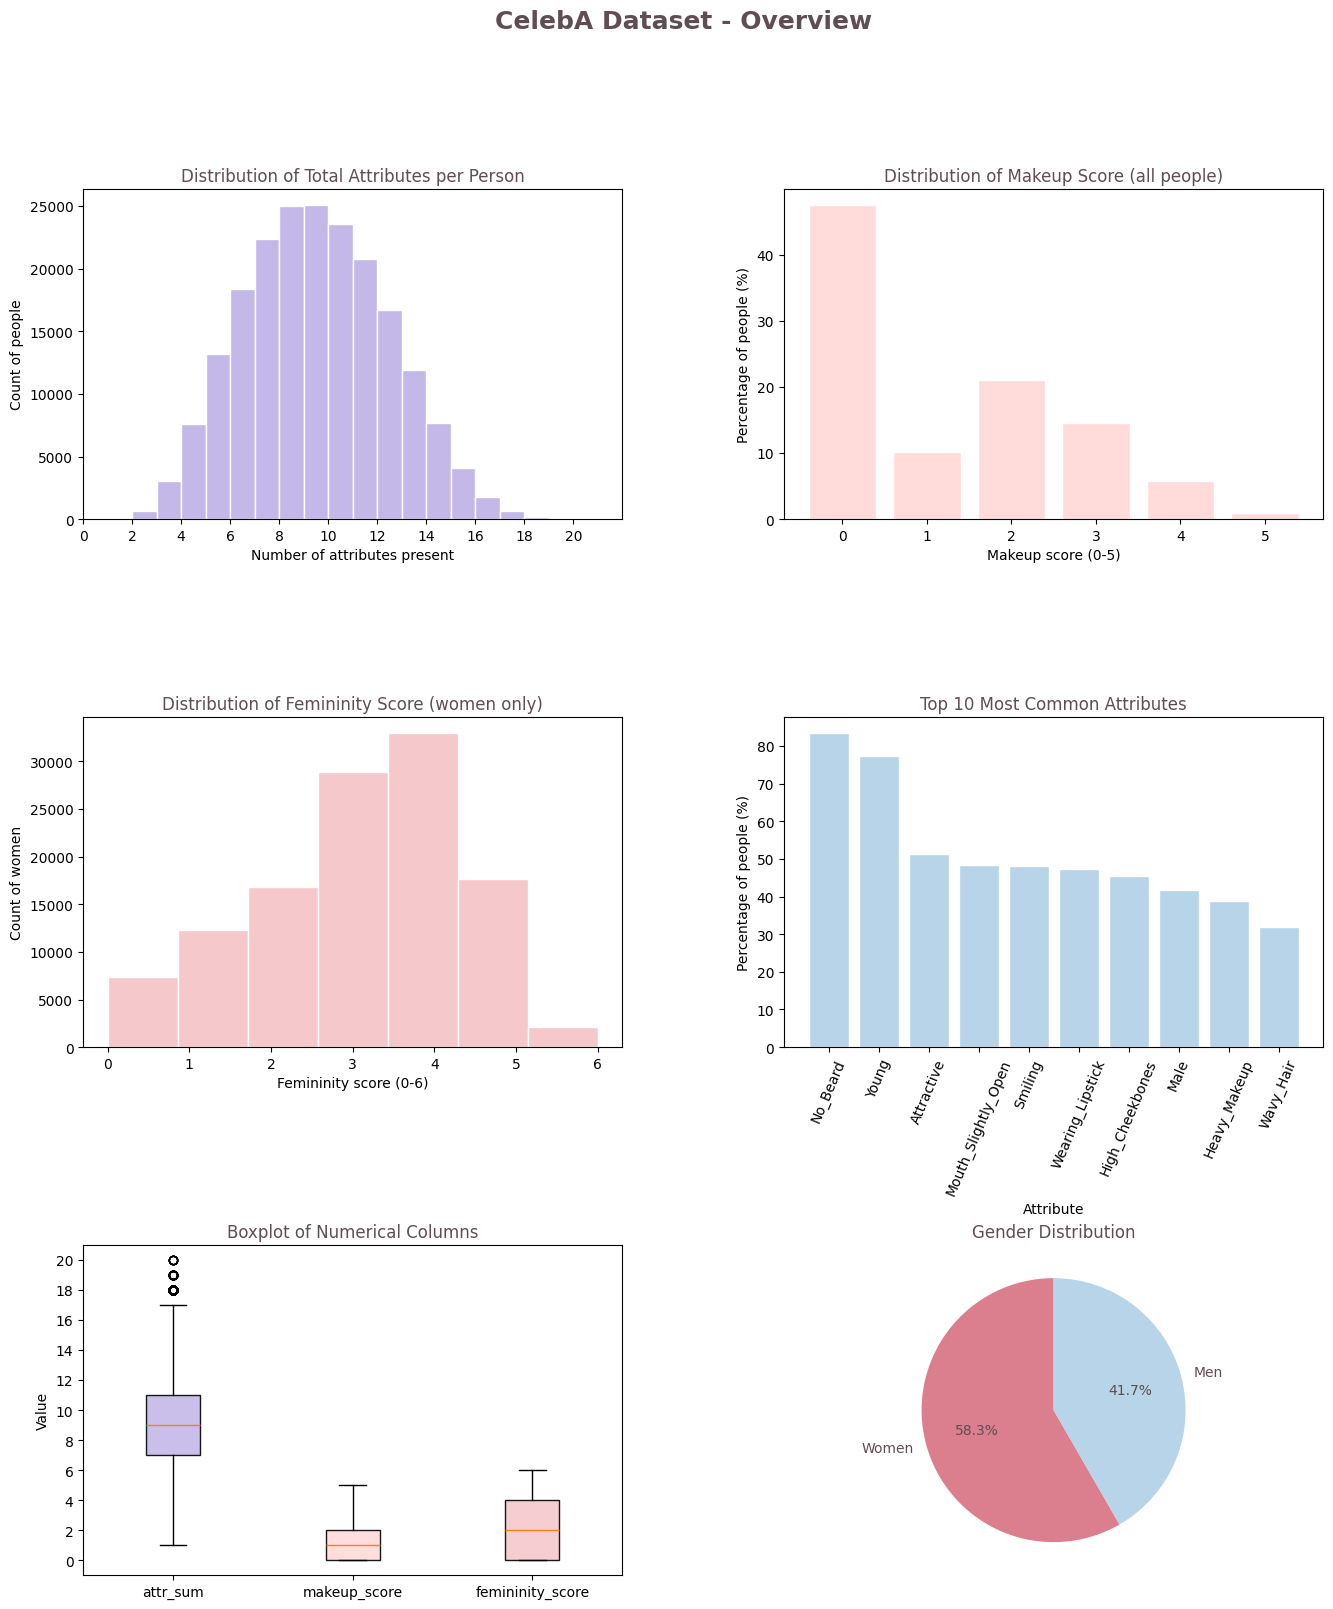

In [7]:
fig, axes = plt.subplots(3, 2, figsize=(16, 18))
fig.suptitle('CelebA Dataset - Overview', fontsize=18, fontweight='bold', color='#604D53')
plt.subplots_adjust(hspace=0.6, wspace=0.3)

c1 = '#FFDBDA'
c2 = '#F5C8CC'
c3 = '#DB7F8E'
c4 = '#C3B8E8'
c5 = '#B8D4E8'
c6 = '#9DA3A4'

# 1)Histogram of attr_sum
min_val = int(df_clean['attr_sum'].min())
max_val = int(df_clean['attr_sum'].max())
axes[0, 0].hist(df_clean['attr_sum'], bins=range(min_val, max_val + 2), 
                color=c4, edgecolor='white')
axes[0, 0].set_title('Distribution of Total Attributes per Person', color='#604D53')
axes[0, 0].set_xlabel('Number of attributes present')
axes[0, 0].set_ylabel('Count of people')
axes[0, 0].set_xticks(range(0, max_val + 1, 2))

# 2)Makeup score
makeup_counts = df_clean['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 1].bar(makeup_counts.index, makeup_counts.values, color=c1, edgecolor='white')
axes[0, 1].set_title('Distribution of Makeup Score (all people)', color='#604D53')
axes[0, 1].set_xlabel('Makeup score (0-5)')
axes[0, 1].set_ylabel('Percentage of people (%)')

# 3)Femininity score
women = df_clean[df_clean['Male'] == 0]
axes[1, 0].hist(women['femininity_score'], bins=7, color=c2, edgecolor='white')
axes[1, 0].set_title('Distribution of Femininity Score (women only)', color='#604D53')
axes[1, 0].set_xlabel('Femininity score (0-6)')
axes[1, 0].set_ylabel('Count of women')

# 4)Top 10 most common attributes
attr_pct = df_clean[df.columns.tolist()].mean().sort_values(ascending=False).head(10) * 100
axes[1, 1].bar(attr_pct.index, attr_pct.values, color=c5, edgecolor='white')
axes[1, 1].set_title('Top 10 Most Common Attributes', color='#604D53')
axes[1, 1].set_xlabel('Attribute')
axes[1, 1].set_ylabel('Percentage of people (%)')
axes[1, 1].tick_params(axis='x', rotation=67)

# 5)Boxplot
bp = axes[2, 0].boxplot(
    [df_clean['attr_sum'], df_clean['makeup_score'], df_clean['femininity_score']],
    tick_labels=['attr_sum', 'makeup_score', 'femininity_score'],
    patch_artist=True
)
box_colors = [c4, c1, c2]
for patch, color in zip(bp['boxes'], box_colors):
    patch.set_facecolor(color)
    patch.set_alpha(0.9)
axes[2, 0].set_title('Boxplot of Numerical Columns', color='#604D53')
axes[2, 0].set_ylabel('Value')
axes[2, 0].set_yticks(range(0, 22, 2))

# 6)Pie chart
gender_counts = df_clean['Male'].value_counts()
axes[2, 1].pie(gender_counts.values, 
               labels=['Women', 'Men'],
               colors=[c3, c5],
               autopct='%1.1f%%',
               startangle=90,
               textprops={'color': '#604D53'})
axes[2, 1].set_title('Gender Distribution', color='#604D53')

plt.show()

**Conclusion:**
1) The distribution of attr_sum follows a roughly normal shape centered around 9. 
2) Approximately half of people have a low makeup_score, which reflects the number of males and females in dataset.
3) Majority of women have their feminity score at 3-4.
4) The top 10 most common attributes include Young, No_Beard and Smiling, suggesting the dataset is dominated by young people.
5) Boxplot summarizes 1, 2, 3 plots among all people.
6) Pie chart shows percentage of men and women in dataset, and the number of women is slightly more numerous.

## 1) Top 10 attributes comparison (except 'male') from the 4th plot : men vs women 

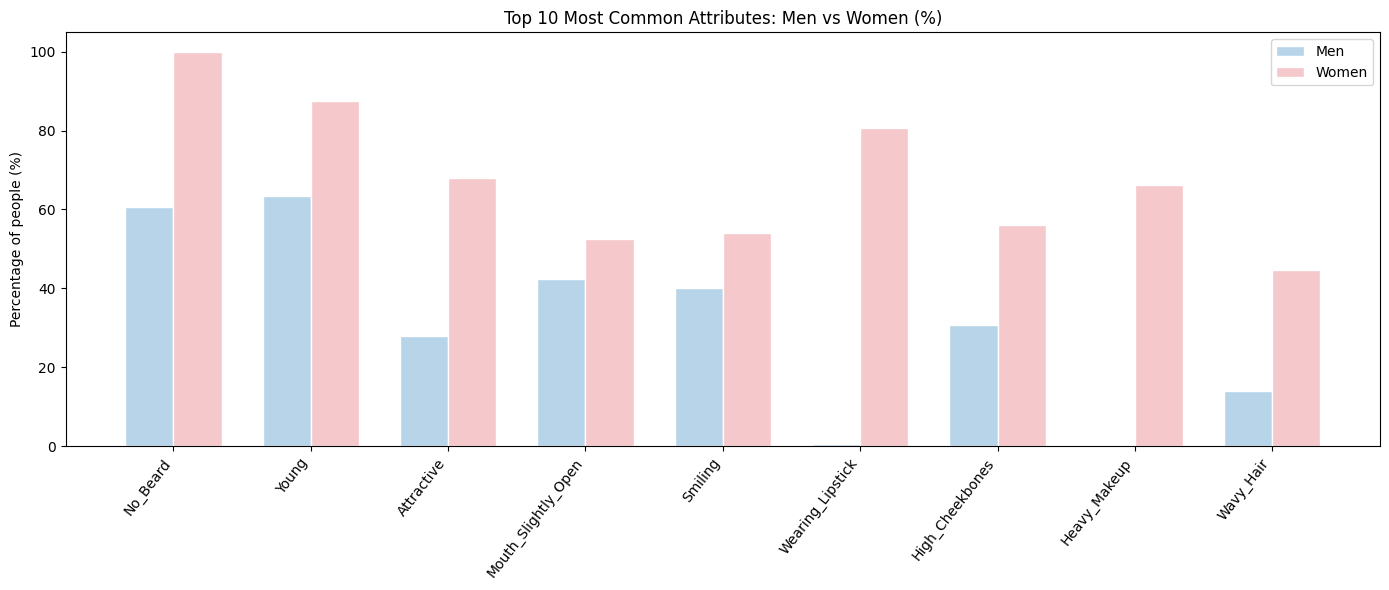

In [8]:
top10_attrs = df_clean[df.columns.tolist()].mean().sort_values(ascending=False).head(10).index.tolist()
top10_attrs = [attr for attr in top10_attrs if attr != 'Male']

men = df_clean[df_clean['Male'] == 1]
women = df_clean[df_clean['Male'] == 0]

men_pct = men[top10_attrs].mean() * 100
women_pct = women[top10_attrs].mean() * 100

x = range(len(top10_attrs))
width = 0.35

fig, ax = plt.subplots(figsize=(14, 6))
ax.bar([i - width/2 for i in x], men_pct, width, label='Men', color='#B8D4E8', edgecolor='white')
ax.bar([i + width/2 for i in x], women_pct, width, label='Women', color='#F5C8CC', edgecolor='white')

ax.set_title('Top 10 Most Common Attributes: Men vs Women (%)')
ax.set_ylabel('Percentage of people (%)')
ax.set_xticks(x)
ax.set_xticklabels(top10_attrs, rotation=52, ha='right')
ax.legend()

plt.tight_layout()
plt.show()

Overall, women show higher rates of every attribute, especially of Smiling, Attractive, Wearing lipstick, Heavy makeup.
Young attribute is high for both genders, so the database is dominated by young people.

## 2) Correlation heatmap of selected attributes (how some attributes are correlating/connected to each other)

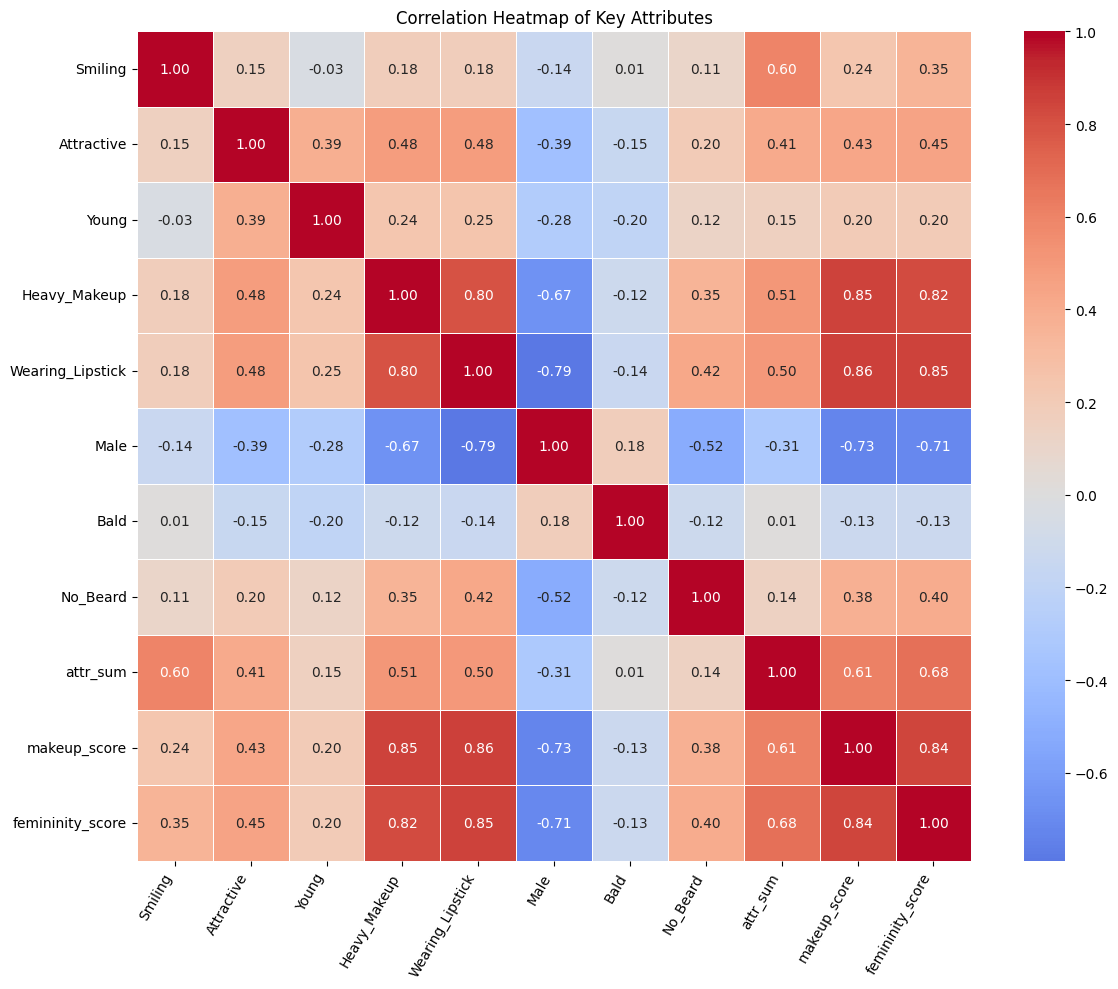

In [9]:
corr_attrs = ['Smiling', 'Attractive', 'Young', 'Heavy_Makeup', 
              'Wearing_Lipstick', 'Male', 'Bald', 'No_Beard',
              'attr_sum', 'makeup_score', 'femininity_score']

corr_matrix = df_clean[corr_attrs].corr().round(2)

fig, ax = plt.subplots(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm', 
            center=0, ax=ax, linewidths=0.5)
ax.set_xticklabels(ax.get_xticklabels(), rotation=60, ha='right')
ax.set_title('Correlation Heatmap of Key Attributes')

plt.tight_layout()
plt.show()

Heatmap shows strong positive correlation between Heavy Makeup, Wearing Lipstick and Attractive Level, especially among women.
Moreover, male attribute shows strong negative correlation with most makeup-related features.
Also, Makeup score and Femininity score are strongly related, because they share several common attributes.

## 3) Makeup score and hair colour distribution: men vs women

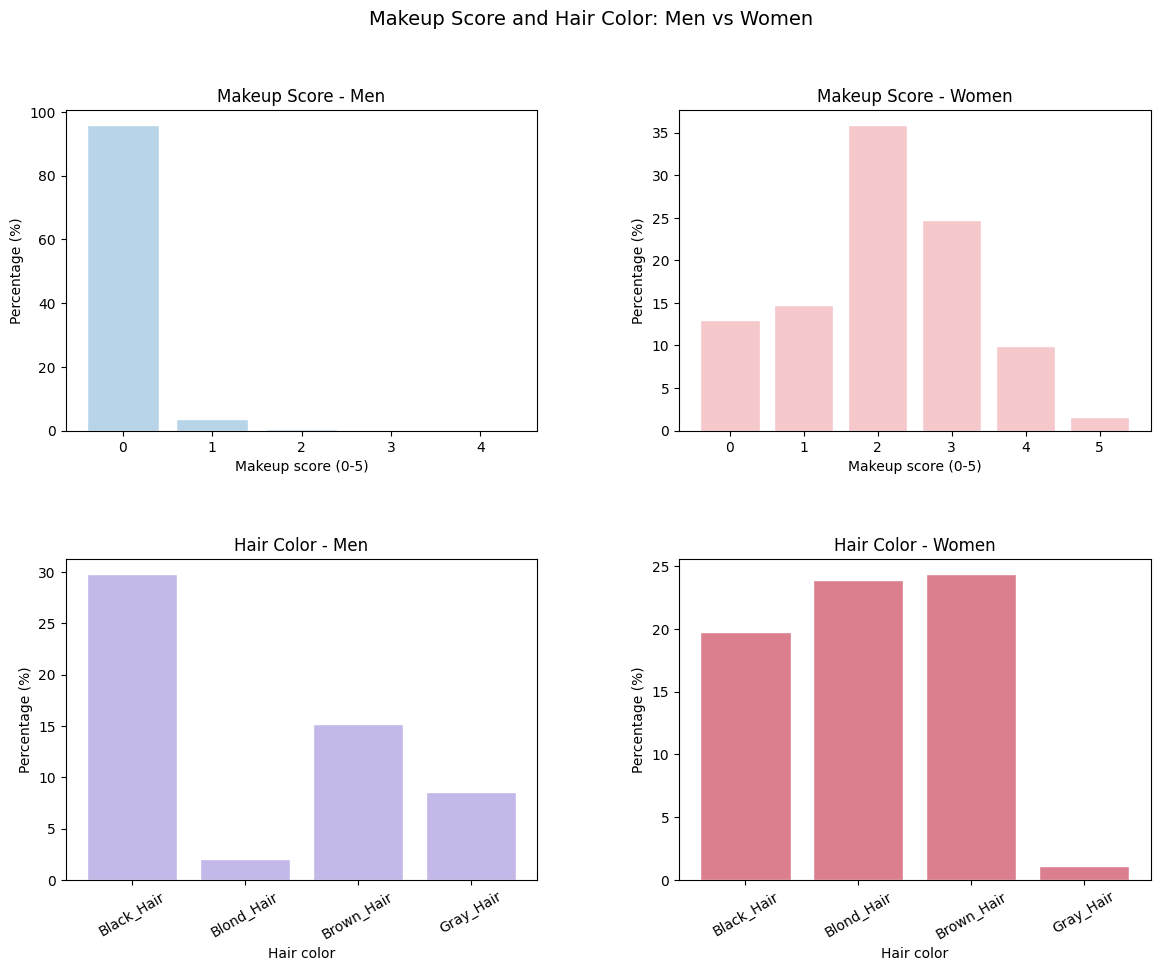

In [10]:
fig, axes = plt.subplots(2, 2, figsize=(14, 10))
fig.suptitle('Makeup Score and Hair Color: Men vs Women', fontsize=14)
plt.subplots_adjust(hspace=0.4, wspace=0.3)

makeup_counts_men = men['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 0].bar(makeup_counts_men.index, makeup_counts_men.values, color='#B8D4E8', edgecolor='white')
axes[0, 0].set_title('Makeup Score - Men')
axes[0, 0].set_xlabel('Makeup score (0-5)')
axes[0, 0].set_ylabel('Percentage (%)')

makeup_counts_women = women['makeup_score'].value_counts(normalize=True).sort_index() * 100
axes[0, 1].bar(makeup_counts_women.index, makeup_counts_women.values, color='#F5C8CC', edgecolor='white')
axes[0, 1].set_title('Makeup Score - Women')
axes[0, 1].set_xlabel('Makeup score (0-5)')
axes[0, 1].set_ylabel('Percentage (%)')

hair_cols = ['Black_Hair', 'Blond_Hair', 'Brown_Hair', 'Gray_Hair']
men_hair = men[hair_cols].mean() * 100
axes[1, 0].bar(hair_cols, men_hair.values, color='#C3B8E8', edgecolor='white')
axes[1, 0].set_title('Hair Color - Men')
axes[1, 0].set_xlabel('Hair color')
axes[1, 0].set_ylabel('Percentage (%)')
axes[1, 0].tick_params(axis='x', rotation=30)

women_hair = women[hair_cols].mean() * 100
axes[1, 1].bar(hair_cols, women_hair.values, color='#DB7F8E', edgecolor='white')
axes[1, 1].set_title('Hair Color - Women')
axes[1, 1].set_xlabel('Hair color')
axes[1, 1].set_ylabel('Percentage (%)')
axes[1, 1].tick_params(axis='x', rotation=30)

plt.show()

Almost 100% of men have makeup score of 0, while women show varied destribution.
One third of women have their makeup score at 2.
Black hair is the most common color among men, while women have more even spread across black, blond, brown hair.
Gray hair is rare for both genders, however is more common for men.

## 4) Attractive vs unattractive correlation with number of attributes and feminity score (for women)

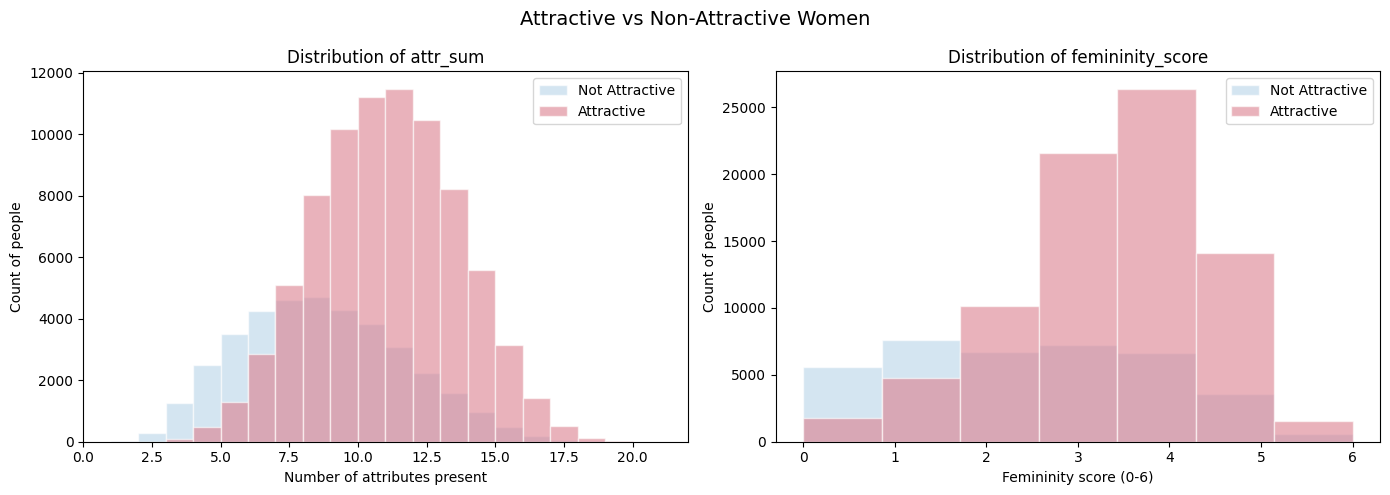

In [11]:
attractive = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 0)]
not_attractive = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Attractive vs Non-Attractive Women', fontsize=14)

axes[0].hist(not_attractive['attr_sum'], bins=range(1, 22), 
             alpha=0.6, color='#B8D4E8', edgecolor='white', label='Not Attractive')
axes[0].hist(attractive['attr_sum'], bins=range(1, 22), 
             alpha=0.6, color='#DB7F8E', edgecolor='white', label='Attractive')
axes[0].set_title('Distribution of attr_sum')
axes[0].set_xlabel('Number of attributes present')
axes[0].set_ylabel('Count of people')
axes[0].legend()

axes[1].hist(not_attractive['femininity_score'], bins=7, 
             alpha=0.6, color='#B8D4E8', edgecolor='white', label='Not Attractive')
axes[1].hist(attractive['femininity_score'], bins=7, 
             alpha=0.6, color='#DB7F8E', edgecolor='white', label='Attractive')
axes[1].set_title('Distribution of femininity_score')
axes[1].set_xlabel('Femininity score (0-6)')
axes[1].set_ylabel('Count of people')
axes[1].legend()

plt.tight_layout()
plt.show()

Attractive women tend to have higher number of attributes, so they have more positively labeled attributes overall.
Their Feminity score is also higher, shifting the distribution towards scores of 3-5 compared to non-attractive women who have 1-3.

# Hypothesis

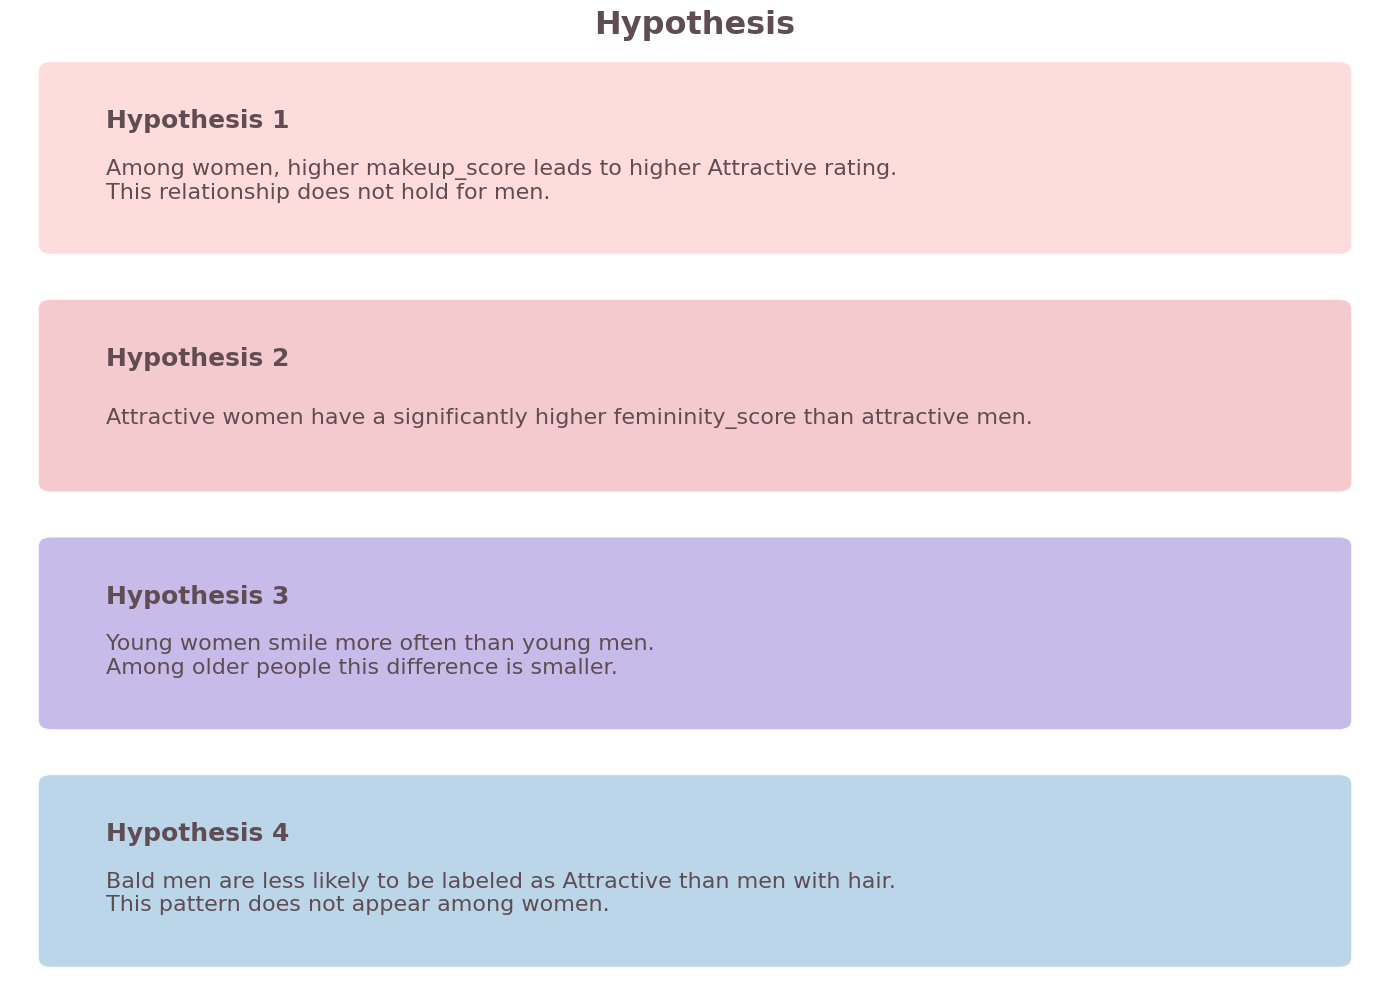

In [25]:
fig, ax = plt.subplots(figsize=(14, 10))
ax.set_xlim(0, 10)
ax.set_ylim(1, 9.5)
ax.axis('off')

ax.set_title('Hypothesis', fontsize=23, 
             fontweight='bold', color='#604D53', pad=20)

hypotheses = [
    ('Hypothesis 1', 
     'Among women, higher makeup_score leads to higher Attractive rating.\n'
     'This relationship does not hold for men.'),
    ('Hypothesis 2',
     'Attractive women have a significantly higher femininity_score than attractive men.'),
    ('Hypothesis 3',
     'Young women smile more often than young men.\n'
     'Among older people this difference is smaller.'),
    ('Hypothesis 4',
     'Bald men are less likely to be labeled as Attractive than men with hair.\n'
     'This pattern does not appear among women.'),
]

colors = ['#FFDBDA', '#F5C8CC', '#C3B8E8', '#B8D4E8']
text_colors = ['#604D53', '#604D53', '#604D53', '#604D53']

for i, (title, text) in enumerate(hypotheses):
    y = 8.5 - i * 2.2

    fancy = mpatches.FancyBboxPatch(
        (0.3, y - 0.7), 9.4, 1.6,
        boxstyle="round,pad=0.1",
        facecolor=colors[i],
        edgecolor='white',
        linewidth=2,
        alpha=0.95
    )
    ax.add_patch(fancy)

    ax.text(0.7, y + 0.45, title,
            ha='left', va='center',
            fontsize=18, fontweight='bold', color=text_colors[i])
    ax.text(0.7, y - 0.1, text,
            ha='left', va='center',
            fontsize=16, color=text_colors[i])

plt.tight_layout()
plt.show()

## Hypothesis 1

Among women, higher makeup_score leads to higher Attractive rating. 
This relationship does not hold for men.

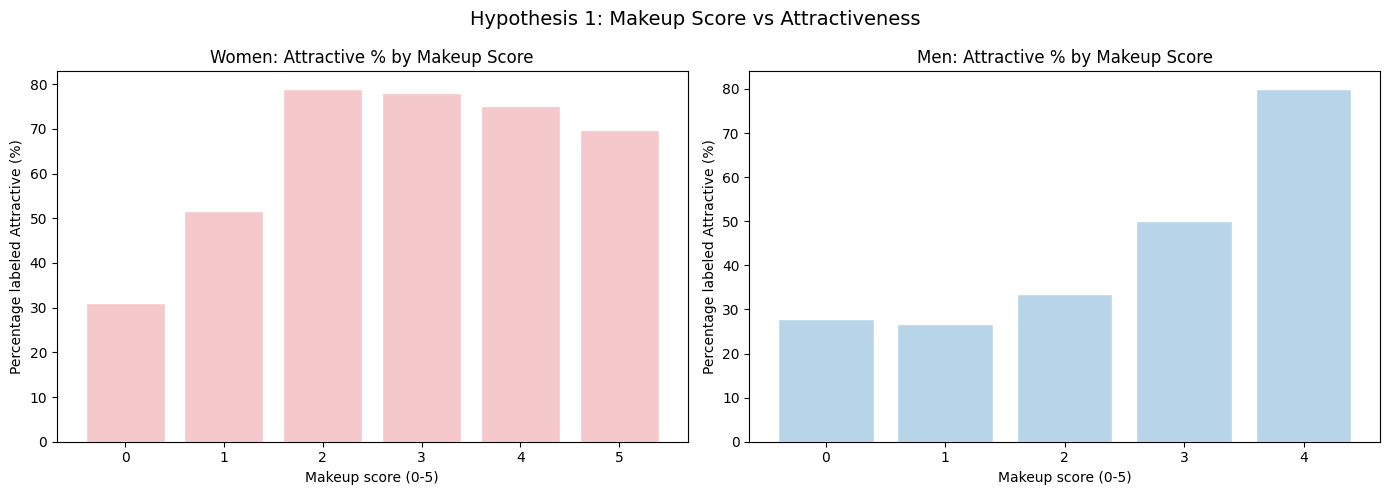

Women - Attractive % by makeup_score:
makeup_score
0    31.0
1    51.7
2    78.9
3    77.9
4    75.1
5    69.8
Name: Attractive, dtype: float64

Men - Attractive % by makeup_score:
makeup_score
0    27.9
1    26.6
2    33.4
3    50.0
4    80.0
Name: Attractive, dtype: float64


In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 1: Makeup Score vs Attractiveness', fontsize=14)

women_grouped = women.groupby('makeup_score')['Attractive'].mean() * 100
axes[0].bar(women_grouped.index, women_grouped.values, color='#F5C8CC', edgecolor='white')
axes[0].set_title('Women: Attractive % by Makeup Score')
axes[0].set_xlabel('Makeup score (0-5)')
axes[0].set_ylabel('Percentage labeled Attractive (%)')

men_grouped = men.groupby('makeup_score')['Attractive'].mean() * 100
axes[1].bar(men_grouped.index, men_grouped.values, color='#B8D4E8', edgecolor='white')
axes[1].set_title('Men: Attractive % by Makeup Score')
axes[1].set_xlabel('Makeup score (0-5)')
axes[1].set_ylabel('Percentage labeled Attractive (%)')

plt.tight_layout()
plt.show()

print("Women - Attractive % by makeup_score:")
print(women_grouped.round(1))
print("\nMen - Attractive % by makeup_score:")
print(men_grouped.round(1))

### Result

Hypothesis 1 is **confirmed** for women: as makeup_score increases from 0 to 2, 
the percentage of women labeled Attractive rises sharply from 31% to 79%.
For men, the pattern also holds but the sample size for higher makeup scores is very small,
so this result is less reliable for males.

## Hypothesis 2

Attractive women have a significantly higher femininity_score than attractive men.
So, for women, attractiveness is more strongly associated with feminine features than for men.

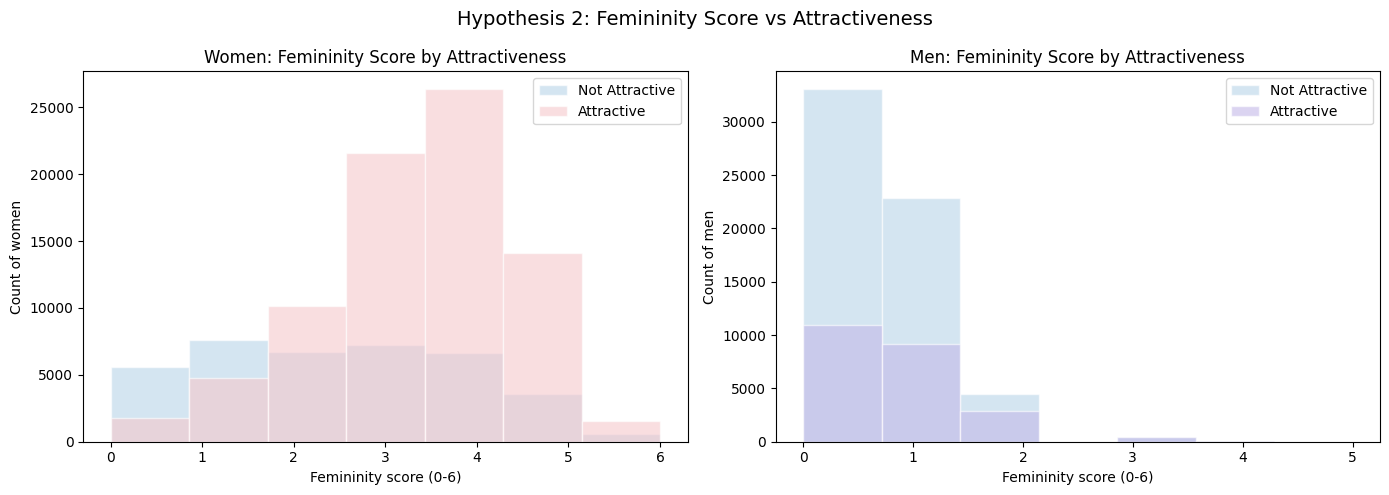

Attractive women - femininity_score mean: 3.43
Not attractive women - femininity_score mean: 2.39

Attractive men - femininity_score mean: 0.71
Not attractive men - femininity_score mean: 0.55


In [14]:
attractive_women = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 0)]
attractive_men = df_clean[(df_clean['Attractive'] == 1) & (df_clean['Male'] == 1)]
not_attractive_women = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 0)]
not_attractive_men = df_clean[(df_clean['Attractive'] == 0) & (df_clean['Male'] == 1)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 2: Femininity Score vs Attractiveness', fontsize=14)

axes[0].hist(not_attractive_women['femininity_score'], bins=7,
             alpha=0.6, color='#B8D4E8', edgecolor='white', label='Not Attractive')
axes[0].hist(attractive_women['femininity_score'], bins=7,
             alpha=0.6, color='#F5C8CC', edgecolor='white', label='Attractive')
axes[0].set_title('Women: Femininity Score by Attractiveness')
axes[0].set_xlabel('Femininity score (0-6)')
axes[0].set_ylabel('Count of women')
axes[0].legend()

axes[1].hist(not_attractive_men['femininity_score'], bins=7,
             alpha=0.6, color='#B8D4E8', edgecolor='white', label='Not Attractive')
axes[1].hist(attractive_men['femininity_score'], bins=7,
             alpha=0.6, color='#C3B8E8', edgecolor='white', label='Attractive')
axes[1].set_title('Men: Femininity Score by Attractiveness')
axes[1].set_xlabel('Femininity score (0-6)')
axes[1].set_ylabel('Count of men')
axes[1].legend()

plt.tight_layout()
plt.show()

print("Attractive women - femininity_score mean:", attractive_women['femininity_score'].mean().round(2))
print("Not attractive women - femininity_score mean:", not_attractive_women['femininity_score'].mean().round(2))
print("\nAttractive men - femininity_score mean:", attractive_men['femininity_score'].mean().round(2))
print("Not attractive men - femininity_score mean:", not_attractive_men['femininity_score'].mean().round(2))

### Result

Hypothesis 2 is **confirmed**. Attractive women have a significantly higher femininity_score (mean: 3.43) compared to non-attractive women (mean: 2.39).
For men, the difference is much smaller (0.71 vs 0.55).
So, feminine features play a much stronger role in female attractiveness ratings rather than in male attractiveness ratings.

## Hypothesis 3

Young women smile more often than young men.
Among older people this difference is smaller.

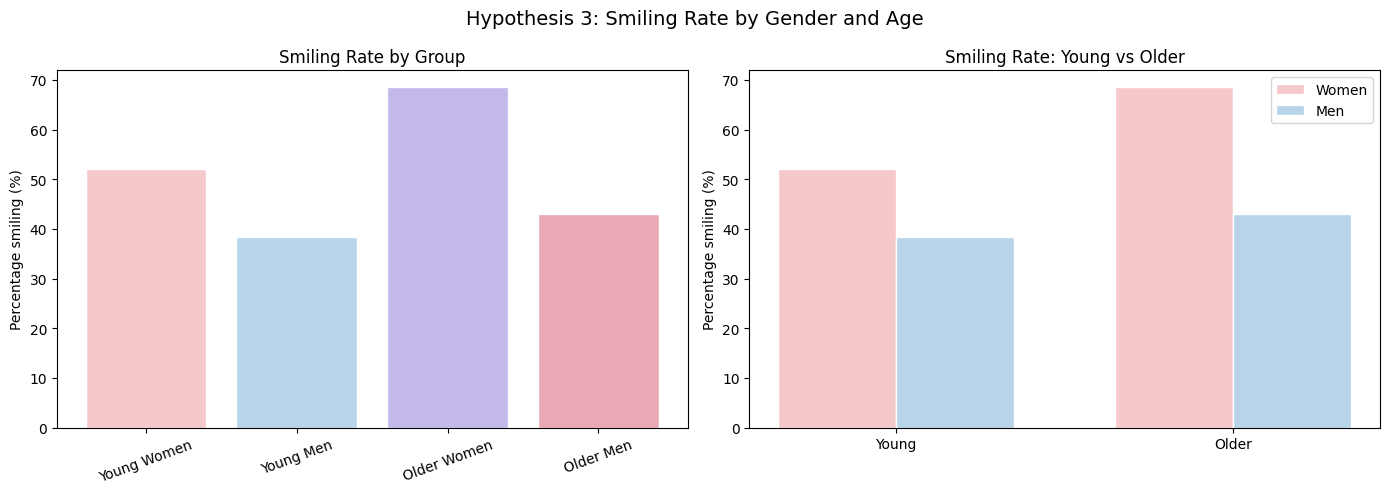

Young women smiling: 52.0%
Young men smiling: 38.3%
Older women smiling: 68.5%
Older men smiling: 43.0%


In [15]:
young_women = df_clean[(df_clean['Young'] == 1) & (df_clean['Male'] == 0)]
young_men = df_clean[(df_clean['Young'] == 1) & (df_clean['Male'] == 1)]
older_women = df_clean[(df_clean['Young'] == 0) & (df_clean['Male'] == 0)]
older_men = df_clean[(df_clean['Young'] == 0) & (df_clean['Male'] == 1)]

groups = ['Young Women', 'Young Men', 'Older Women', 'Older Men']
smiling_pct = [
    young_women['Smiling'].mean() * 100,
    young_men['Smiling'].mean() * 100,
    older_women['Smiling'].mean() * 100,
    older_men['Smiling'].mean() * 100
]
colors = ['#F5C8CC', '#B8D4E8', '#C3B8E8', '#E8A8B4']

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 3: Smiling Rate by Gender and Age', fontsize=14)

axes[0].bar(groups, smiling_pct, color=colors, edgecolor='white')
axes[0].set_title('Smiling Rate by Group')
axes[0].set_ylabel('Percentage smiling (%)')
axes[0].tick_params(axis='x', rotation=20)

x = [0, 1]
width = 0.35
axes[1].bar([i - width/2 for i in x], 
            [young_women['Smiling'].mean() * 100, older_women['Smiling'].mean() * 100],
            width, label='Women', color='#F5C8CC', edgecolor='white')
axes[1].bar([i + width/2 for i in x],
            [young_men['Smiling'].mean() * 100, older_men['Smiling'].mean() * 100],
            width, label='Men', color='#B8D4E8', edgecolor='white')
axes[1].set_title('Smiling Rate: Young vs Older')
axes[1].set_ylabel('Percentage smiling (%)')
axes[1].set_xticks(x)
axes[1].set_xticklabels(['Young', 'Older'])
axes[1].legend()

plt.tight_layout()
plt.show()

print(f"Young women smiling: {young_women['Smiling'].mean()*100:.1f}%")
print(f"Young men smiling: {young_men['Smiling'].mean()*100:.1f}%")
print(f"Older women smiling: {older_women['Smiling'].mean()*100:.1f}%")
print(f"Older men smiling: {older_men['Smiling'].mean()*100:.1f}%")

### Result

Hypothesis 3 is **partially confirmed**. Young women smile ~13.7% more often than young men (52.0% vs. 38.3%). However, the second part of the hypothesis was incorrect and among older people the gap is even larger - 25.5% (68.5% vs 43.0%), not smaller as was expected.

## Hypothesis 4

Bald men are less likely to be labeled as Attractive than men with hair.
This pattern does not appear among women since very few women in the dataset are bald.

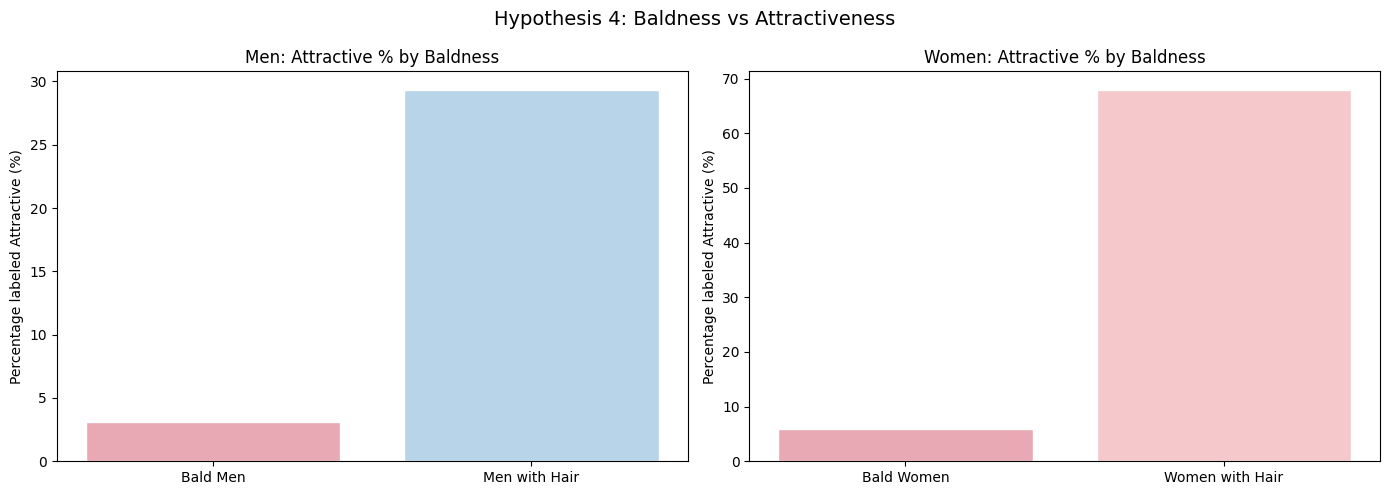

Bald men - Attractive: 3.1%
Men with hair - Attractive: 29.3%

Bald women - Attractive: 5.9%
Women with hair - Attractive: 67.9%

Number of bald women in dataset: 17
Number of bald men in dataset: 4530


In [16]:
bald_men = df_clean[(df_clean['Bald'] == 1) & (df_clean['Male'] == 1)]
haired_men = df_clean[(df_clean['Bald'] == 0) & (df_clean['Male'] == 1)]
bald_women = df_clean[(df_clean['Bald'] == 1) & (df_clean['Male'] == 0)]
haired_women = df_clean[(df_clean['Bald'] == 0) & (df_clean['Male'] == 0)]

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Hypothesis 4: Baldness vs Attractiveness', fontsize=14)

groups_men = ['Bald Men', 'Men with Hair']
values_men = [bald_men['Attractive'].mean() * 100, 
              haired_men['Attractive'].mean() * 100]
axes[0].bar(groups_men, values_men, color=['#E8A8B4', '#B8D4E8'], edgecolor='white')
axes[0].set_title('Men: Attractive % by Baldness')
axes[0].set_ylabel('Percentage labeled Attractive (%)')

groups_women = ['Bald Women', 'Women with Hair']
values_women = [bald_women['Attractive'].mean() * 100,
                haired_women['Attractive'].mean() * 100]
axes[1].bar(groups_women, values_women, color=['#E8A8B4', '#F5C8CC'], edgecolor='white')
axes[1].set_title('Women: Attractive % by Baldness')
axes[1].set_ylabel('Percentage labeled Attractive (%)')

plt.tight_layout()
plt.show()

print(f"Bald men - Attractive: {bald_men['Attractive'].mean()*100:.1f}%")
print(f"Men with hair - Attractive: {haired_men['Attractive'].mean()*100:.1f}%")
print(f"\nBald women - Attractive: {bald_women['Attractive'].mean()*100:.1f}%")
print(f"Women with hair - Attractive: {haired_women['Attractive'].mean()*100:.1f}%")
print(f"\nNumber of bald women in dataset: {len(bald_women)}")
print(f"Number of bald men in dataset: {len(bald_men)}")

### Result

Hypothesis 4 is **confirmed** for men: bald men are labeled as attractive  significantly less often than men with hair (3.1% vs 29.3%).
But he same pattern appears even stronger among women (5.9% vs 67.9%), however the sample of bald women is very small (only 17 out of 202 599 images), that is why this result for women is unreliable.